# Day 3 — The P-H Diagram (Saturation Dome)
**Mahesha Gonal — Refrigeration Simulation Portfolio**

**In plain terms:** think of a Pressure–Enthalpy (P-H) diagram as a map of every possible condition R134a can be in.

- The **left (blue) curve** = saturated liquid — 100% liquid, no vapour yet.
- The **right (red) curve** = saturated vapour — 100% vapour, no liquid left.
- **Inside the dome** (between the two curves) = a liquid/vapour mixture — this is exactly where evaporation and condensation happen inside a real evaporator/condenser coil.
- **Outside the dome** = either pure subcooled liquid (left) or pure superheated vapour (right).

The dashed green lines are **isotherms** (constant-temperature lines) — they go flat inside the dome (because boiling happens at a fixed temperature for a fixed pressure) and curve once outside it.

Every later notebook in this series plots cycles *on top of* this same map.

In [1]:
# CELL 1 — Install dependencies (run this first, every time)
!pip install coolprop matplotlib numpy PyGithub -q

In [2]:
# CELL 2 — Imports
import CoolProp.CoolProp as CP
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# CELL 3 — Build the saturation dome for R134a
refrigerant = "R134a"
T_min  = CP.PropsSI("Tmin",  refrigerant) + 5
T_crit = CP.PropsSI("Tcrit", refrigerant) - 0.1
T_range = np.linspace(T_min, T_crit, 300)

h_liq = [CP.PropsSI("H","T",T,"Q",0,refrigerant)/1000 for T in T_range]
P_liq = [CP.PropsSI("P","T",T,"Q",0,refrigerant)/1e5  for T in T_range]
h_vap = [CP.PropsSI("H","T",T,"Q",1,refrigerant)/1000 for T in T_range]
P_vap = [CP.PropsSI("P","T",T,"Q",1,refrigerant)/1e5  for T in T_range]
h_crit = CP.PropsSI("H","T",T_crit,"Q",0,refrigerant)/1000
P_crit = CP.PropsSI("P","T",T_crit,"Q",0,refrigerant)/1e5

print(f"Dome built from {T_min-273.15:.1f}C up to the critical point at {T_crit-273.15:.1f}C")

Dome built from -98.3C up to the critical point at 101.0C


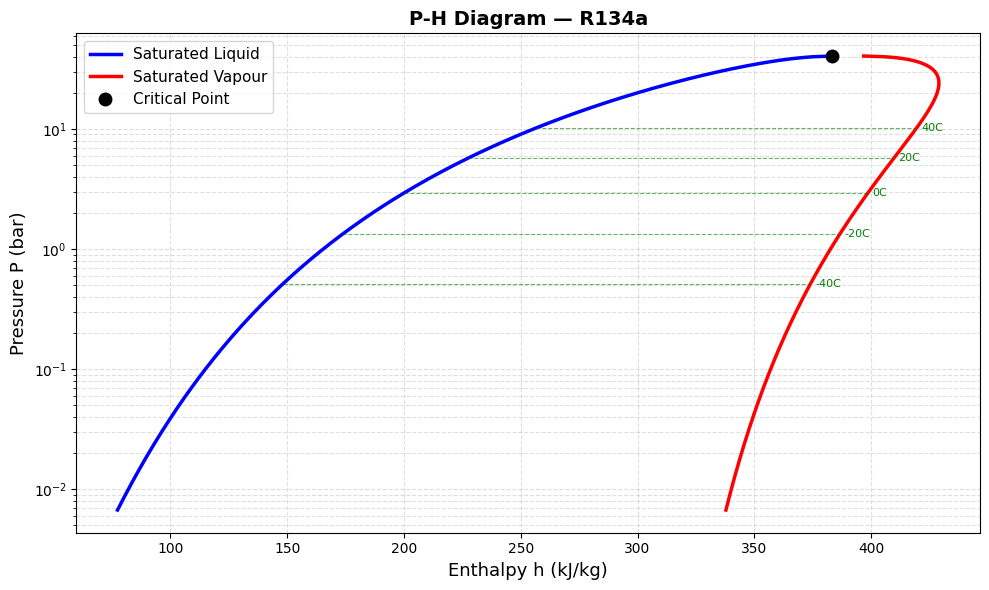

In [4]:
# CELL 4 — Plot the dome with isotherms
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(h_liq, P_liq, "b-", linewidth=2.5, label="Saturated Liquid")
ax.plot(h_vap, P_vap, "r-", linewidth=2.5, label="Saturated Vapour")
ax.plot(h_crit, P_crit, "ko", markersize=9, label="Critical Point")

for T_C in [-40,-20,0,20,40]:
    T_K = T_C + 273.15
    if T_K < CP.PropsSI("Tcrit", refrigerant):
        P_s = CP.PropsSI("P","T",T_K,"Q",0,refrigerant)/1e5
        h_l = CP.PropsSI("H","T",T_K,"Q",0,refrigerant)/1000
        h_v = CP.PropsSI("H","T",T_K,"Q",1,refrigerant)/1000
        ax.plot([h_l,h_v],[P_s,P_s],"g--",linewidth=0.8,alpha=0.6)
        ax.text(h_v+2, P_s, f"{T_C}C", fontsize=8, color="green", va="center")

ax.set_yscale("log")
ax.set_xlabel("Enthalpy h (kJ/kg)", fontsize=13)
ax.set_ylabel("Pressure P (bar)",   fontsize=13)
ax.set_title("P-H Diagram — R134a", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("day03_ph_diagram.png", dpi=150)
plt.show()

**What this graph tells us:** the dome shape narrows to a point at the top — that's the **critical point**, above which liquid and vapour stop being distinguishable. For R134a that happens just above 100°C, far hotter than any condenser in a refrigerator runs at, so we never need to worry about operating past it in normal use.

The pressure axis is on a **log scale** because refrigeration pressures span a wide range (well under 1 bar at deep-freeze temperatures, up to 15+ bar at hot condensing temperatures) — a log scale keeps both ends readable on one chart.

In [ ]:
# FINAL CELL — Push this notebook to GitHub
from github import Github, Auth
from google.colab import userdata, _message
import json

token = userdata.get('GITHUB_TOKEN')
auth = Auth.Token(token)
g = Github(auth=auth)
repo = g.get_repo("MaheshaGonal/refrigeration-simulation-python")

nb_data = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
content = json.dumps(nb_data['ipynb'], indent=1)

filename = "day03_ph_diagram.ipynb"

try:
    existing = repo.get_contents(filename)
    repo.update_file(filename, "Add Day 03 - P-H diagram saturation dome with isotherms", content, existing.sha)
    print("Updated existing file on GitHub")
except Exception:
    repo.create_file(filename, "Add Day 03 - P-H diagram saturation dome with isotherms", content)
    print("Created new file on GitHub")

print("GitHub repo: https://github.com/MaheshaGonal/refrigeration-simulation-python")
